In [33]:
from datasets import load_dataset
ds = load_dataset("Fumika/Wikinews-multilingual")
texts = ds["train"]["text"]
corpus = " ".join(" ".join(t) if isinstance(t, list) else t for t in texts)


In [34]:
import re
from collections import Counter

tokens = re.findall(r"[A-Za-zÀ-ž]+", corpus.lower())

vocab_size = 10000
word_counts = Counter(tokens)

min_freq = 5
filtered = [w for w, c in word_counts.items() if c >= min_freq]

# Keep top 9999 + UNK
vocab = filtered[:9999]
vocab.append("<UNK>")

# Mapping
word_to_index = {word: i for i, word in enumerate(vocab)}

def replace_unk(word):
    return word if word in word_to_index else "<UNK>"

tokens = [replace_unk(w) for w in tokens]

In [35]:

window_size = 2
training_data = []

for i in range(window_size, len(tokens) - window_size):
    context = tokens[i-window_size:i] + tokens[i+1:i+window_size+1]
    target = tokens[i]
    training_data.append((context, target))

len(training_data)

3596694

In [38]:
import numpy as np

# -----------------------------
# Model initialization
# -----------------------------
V = len(vocab)      # vocabulary size
D = 200
            # embedding dimension

E = np.random.randn(V, D) * 0.01   # embedding matrix
W = np.random.randn(D, V) * 0.01   # output weights
b = np.zeros(V)                    # output bias


# -----------------------------
# Forward pass
# -----------------------------
def forward(context_indices):
    # average context embeddings
    v_context = np.mean(E[context_indices], axis=0)

    # logits
    z = np.dot(v_context, W) + b

    # numerically stable softmax
    z_shift = z - np.max(z)
    y_pred = np.exp(z_shift) / np.sum(np.exp(z_shift))

    return v_context, y_pred


# -----------------------------
# Loss (cross entropy)
# -----------------------------
def loss(y_pred, target_idx):
    return -np.log(y_pred[target_idx] + 1e-9)


# -----------------------------
# Backward pass (SGD update)
# -----------------------------
def backward(v_context, y_pred, target_idx, context_indices, lr=0.01):
    global E, W, b

    # one-hot target
    y = np.zeros_like(y_pred)
    y[target_idx] = 1

    # error signal
    error = y_pred - y

    # gradients
    dW = np.outer(v_context, error)
    db = error
    dv = np.dot(W, error)

    # update embeddings
    for idx in context_indices:
        E[idx] -= lr * dv / len(context_indices)

    # update output layer
    W -= lr * dW
    b -= lr * db


In [41]:
training_subset = training_data[:30000]

for epoch in range(5):
    total_loss = 0

    for context, target in training_subset:
        context_indices = [word_to_index[w] for w in context]
        target_idx = word_to_index[target]

        v_context, y_pred = forward(context_indices)
        total_loss += loss(y_pred, target_idx)

        backward(v_context, y_pred, target_idx, context_indices)

    print(f"Epoch {epoch}: Loss = {total_loss}")


Epoch 0: Loss = 203274.60552860738
Epoch 1: Loss = 200785.4594059845
Epoch 2: Loss = 198844.6284823047
Epoch 3: Loss = 197076.58932825687
Epoch 4: Loss = 195395.90043170511


In [42]:
from numpy.linalg import norm

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

def nearest_words(word, top_n=5):
    idx = word_to_index[word]
    vec = E[idx]

    sims = []
    for i in range(len(vocab)):
        sim = cosine_similarity(vec, E[i])
        sims.append((vocab[i], sim))

    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[1:top_n+1]


In [43]:
def nearest_words(word, top_n=5):
    if word not in word_to_index:
        return f"'{word}' not in vocabulary"

    idx = word_to_index[word]
    vec = E[idx]

    sims = []
    for i in range(len(vocab)):
        sim = cosine_similarity(vec, E[i])
        sims.append((vocab[i], sim))

    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[1:top_n+1]


In [44]:
stopwords = {"the","of","in","to","and","a","is","it","as","on","for","that","was","were","are","by","with","at","from"}

# remove stopwords
filtered = [w for w in vocab if w not in stopwords]

# remove words with very small embedding norm (low information)
filtered = [w for w in filtered if np.linalg.norm(E[word_to_index[w]]) > 0.5]

selected_words = filtered[:100]
vectors = np.array([E[word_to_index[w]] for w in selected_words])


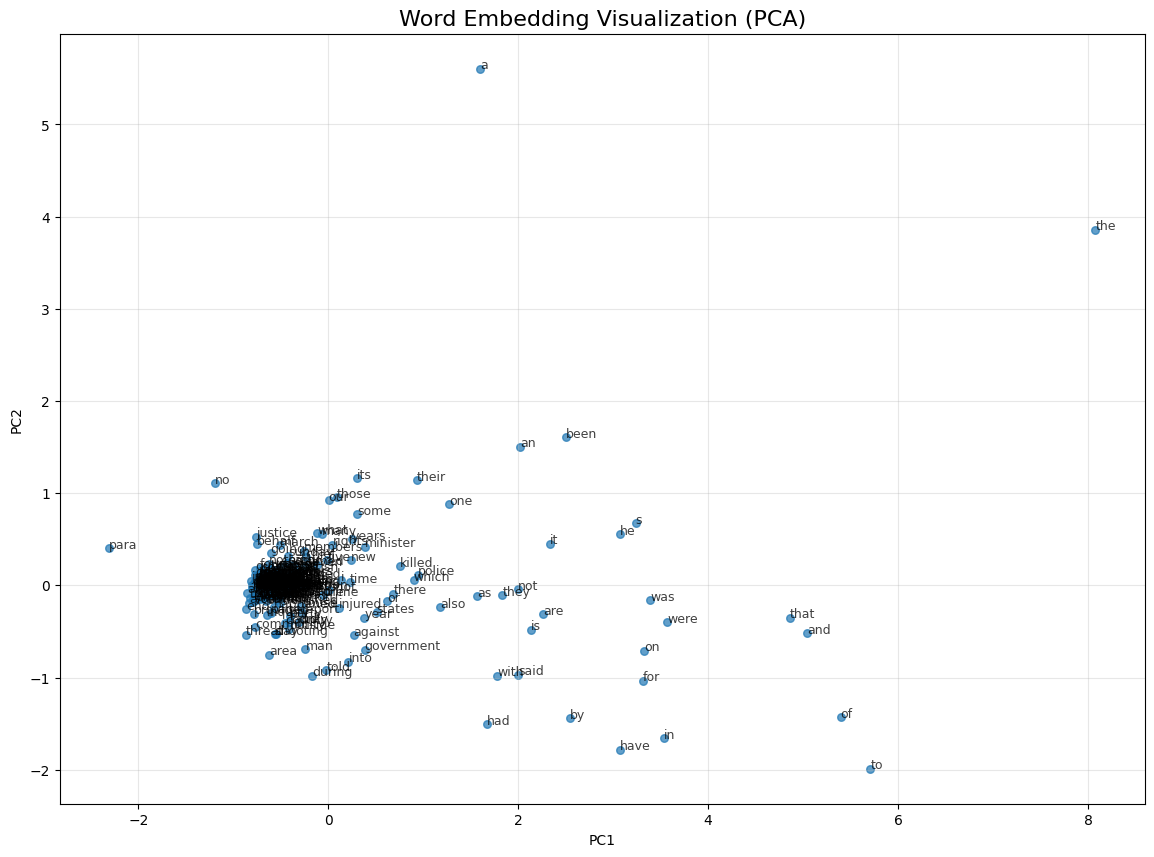

In [45]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# pick 200 frequent words
words_to_plot = vocab[:200]
vectors = E[:200]

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(reduced[:, 0], reduced[:, 1], s=30, alpha=0.7)

for i, word in enumerate(words_to_plot):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.75)

plt.title("Word Embedding Visualization (PCA)", fontsize=16)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


In [46]:
def analogy(a, b, c, top_n=5):
    if a not in word_to_index or b not in word_to_index or c not in word_to_index:
        return "One of the words is not in vocabulary."

    vec = E[word_to_index[b]] - E[word_to_index[a]] + E[word_to_index[c]]

    sims = [(vocab[i], cosine_similarity(vec, E[i])) for i in range(V)]
    sims.sort(key=lambda x: x[1], reverse=True)

    return sims[:top_n]


In [24]:
print("Bias Test: man : woman = doctor : ?")
print(analogy("man", "woman", "doctor"))


Bias Test: man : woman = doctor : ?
One of the words is not in vocabulary.


In [47]:
print(vocab[:200])


['on', 'tuesday', 'the', 'bloody', 'sunday', 'inquiry', 'published', 'its', 'report', 'into', 'british', 'army', 'killing', 'of', 'fourteen', 'civil', 'rights', 'activists', 'in', 'northern', 'ireland', 'a', 'twelve', 'year', 'long', 'public', 'fatal', 'shooting', 'their', 'page', 'stating', 'deaths', 'were', 'unjustified', 'events', 'saw', 'soldiers', 'open', 'fire', 'civilians', 'during', 'march', 'family', 'members', 'and', 'supporters', 'victims', 'reacted', 'positively', 'to', 'as', 'they', 'gathering', 'outside', 'what', 'happened', 'was', 'both', 'it', 'wrong', 'prime', 'minister', 'david', 'cameron', 'told', 'house', 'commons', 'he', 'also', 'said', 't', 'government', 'is', 'ultimately', 'responsible', 'for', 'conduct', 'armed', 'forces', 'that', 'behalf', 'indeed', 'our', 'country', 'i', 'am', 'deeply', 'sorry', 'here', 'no', 'doubt', 'there', 's', 'nothing', 'are', 'states', 'those', 'killed', 'did', 'not', 'pose', 'threat', 'some', 'injured', 'clearly', 'fleeing', 'or', 'goi

In [48]:
print("Bias Test: army : soldiers = police : ?")
print(analogy("army", "soldiers", "police"))


Bias Test: army : soldiers = police : ?
[('police', np.float64(0.9866947441211288)), ('authorities', np.float64(0.8659575214624226)), ('died', np.float64(0.8325885697013082)), ('four', np.float64(0.8307671806085841)), ('yesterday', np.float64(0.8279133669685026))]
